---
title: "Image Classification of Handwritten Digits with fastai"
format:
  html:
    toc: true
date: 2025-06-02
image: 'images/MNIST_batch.png'
description: "Build and train a neural network to recognize handwritten digits using the fastai library."
categories: [neural network, MNIST, imagery, python, fastai]
---

# Overview

This post follows the content presented in [Chapter 4](https://colab.research.google.com/github/fastai/fastbook/blob/master/04_mnist_basics.ipynb) of the fast.ai book, "Deep Learning for Coders with fastai & PyTorch". I've already written two related posts: [ML Basics](../posts/ML_basics.html), which introduces gradient descent and optimization, and [Neural Networks from Scratch](../posts/ML_GP.html), which covers foundational concepts behind deep learning models. While understanding the theory is essential, it's far more efficient to use established libraries once the core ideas are clear.

In this post, I’ll show how to use the `fastai` library—a high-level wrapper around `PyTorch`—to build a neural network that classifies handwritten digits, starting with a binary classification task (distinguishing between 3s and 7s), then expanding to all 10 digits (0–9).



# Binary MNIST classification

We will be working with MNIST, Modified National Institute of Standards and Technology dataset, which is a commonly-used dataset of handwritten digits for training image classification models. The `fastai` package is already loaded with a sample of the data, containing images of 3's and 7's. Let's download it.

In [1]:
from fastai.vision.all import *
from typing import Literal

In [4]:
# download data
path = untar_data(URLs.MNIST_SAMPLE)

The data got stored in a hidden folder somewhere in my home directory. I check out the contents within the directory below. The csv file contains a spreadsheet with 2 columns--file name and the label. We don't use that. The folder for 'train' and 'valid' contain training and validation images, respectively, for the 3 and 7 digits.

In [45]:
[child.name for child in path.ls()]

['train', 'labels.csv', 'valid']

As you can see, we have about equal training and validation data for 3 and 7 and there's about 6x as much training data than validation data.

In [46]:
for dataset in ['train', 'valid']:
    for digit in ['3', '7']:
        print(f"Number of images in {dataset}/{digit}: {len((path/dataset/digit).ls())}")


Number of images in train/3: 6131
Number of images in train/7: 6265
Number of images in valid/3: 1010
Number of images in valid/7: 1028


Let's see what one of those images look like. I'll show the image using a `pandas` dataframe so that you can see the values of the pixels. The cells range between 0 and 255, with 255 being the maximum intensity value for a pixel in an 8-bit grayscale or color image. Also, all of these images are all 28x28 pixels, with a total of 784 cells.

In [3]:
img = (path/'train'/'7').ls()[0]
img = Image.open(img)
print(f"Image dimension: {img.shape}")
pd.DataFrame(array(img)[5:20, 10:21]).style.background_gradient('Greys').set_properties(**{'font-size': '6pt'})

Image dimension: (28, 28)


,0,1,2,3,4,5,6,7,8,9,10
0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0
2,252,254,252,252,252,254,252,252,252,255,252
3,250,252,250,250,250,252,250,250,250,252,250
4,250,252,250,250,250,252,250,250,250,252,189
5,49,49,49,49,49,49,49,170,250,252,149
6,0,0,0,0,0,11,132,252,252,244,121
7,0,0,0,0,0,51,250,250,250,202,0
8,0,0,0,0,0,172,250,250,250,80,0
9,0,0,0,0,0,252,250,250,250,0,0


## Load up the data

We want to load every image in the dataset while maintaining the split between training and validation, as well as the identity of the digits. There is a faster way to do this with an `ImageDataLoaders` class and I will show you that in the next section. For now, let's break down the steps more manually. I wrote a function below that loads the images, converts them into tensors, then stacks them, and normalizes the values to be between 0 and 1.

In [66]:
def load_stack_imgs(number, dataset: Literal['train', 'valid']):
    # load the numbers as images
    imgs = [tensor(Image.open(img)) for img in (path/dataset/str(number)).ls()]

    # stack them, normalizing the values to be between 0-1
    return torch.stack(imgs).float()/255

In [67]:
# load the numbers--training and validation
train_threes = load_stack_imgs(3, 'train')
train_sevens = load_stack_imgs(7, 'train')
valid_threes = load_stack_imgs(3, 'valid')
valid_sevens = load_stack_imgs(7, 'valid')

# number of pixels
npixels = 28*28

Next, we'll create a `DataLoader` object, which will join the data (`x`, i.e. the images) and the labels (`y`, i.e. binary 0/1 codes for 3 vs. 7). `DataLoader` is native to `PyTorch` and is also used in `fastai` to form the basis of the `Learner` class (more on that in the next section). The data and labels will contain both 3's and 7's, but I still keep the training data separate from the validation data.

I wrote a function below that creates 2-rank tensors for both `x` and `y`. `y` will have N rows, where N = total number of images, and 1 column, which will be either a 0 or 1. I arbitrarily chose 0 to represent a 3 and 1 to be a 7. They are dummy variables. Likewise, `x` will also have N rows, but it will have 784 columns, which refers to all the pixels contained in each image. `x` starts as a 3-rank tensor, with dimension N, Width, Height. In convolutional neural networks, we'd want to retain this 3D structure so that the models can learn about the spatial arrangement of the images. But in simple neural nets, we're going to ignore that and collapse each row's data into a vector. That's what `x.view(x.size(0), -1)` does.

In [74]:
def create_dl_binary(data_list, batch_size = 256):
    '''Creates a DataLoader object, which combines the x and y values of a dataset.
    assumes data is binary--only 2 types of images and y can only be 0 or 1.
    '''
    # create tensors that combine all the training data--x and y
    x = torch.cat(data_list)
    y = tensor(len(data_list[0])*[0] + len(data_list[1])*[1]).float()

    # make the predictors and response both 2-rank tensors
    x = x.view(x.size(0), -1) # turns list of matrices into single matrix by flattening each matrix into vector
    y = y.unsqueeze(1) # turns vector into matrix

    # combine into a list of tuples for pytorch
    dset = list(zip(x, y))

    # create a DataLoader object
    return DataLoader(dset, batch_size=batch_size)




In [75]:
train_dl = create_dl_binary([train_threes, train_sevens])
valid_dl = create_dl_binary([valid_threes, valid_sevens])

The resulting dataloader objects are split into batches, each with 256 rows of data (except for the last batch, which might have less). Below, I verify that `x` and `y` have the same number of samples and `x` has 784 coefficients--one for each pixel, and `y` has 1 label for each image.

In [76]:
xb, yb = first(train_dl)
xb.shape, yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

## Create a Learner object

The `Learner` class is specific to `fastai` and is a way to simplify the training of a neural network. Similar to the optimization class that I wrote in my [last blog post](../posts/ML_GP.html), the `Learner` class contains the following:

- The data as `DataLoaders` objects
- Model that makes predictions
- Loss function
- Optimizer
- A function that calculates the overall accuracy

*DataLoaders objects*

To assemble the `DataLoaders`, I simply combine the training and validation `DataLoader` objects that I made above.

In [77]:
# data loaders
dls = DataLoaders(train_dl, valid_dl)

*Model function*

To create a neural network, I can use the `nn.Module` from `PyTorch`.

In [78]:
# prediction function
def nn_1hidden(nodes, coefs = npixels):
    return nn.Sequential(
        nn.Linear(coefs, nodes),
        nn.ReLU(),
        nn.Linear(nodes, 1),
        nn.Sigmoid()
    )


The code cell above is equivalent to this:
$$
\begin{aligned}
\text{layer}_1 &= ReLU(XW_1 + b_1) \\
\hat{y} &= \text{inv-logit}(\text{layer}_1W_2 + b_2) \\
\end{aligned}
$$

This model is very similar to the one I used to fit the GP model in my previous blog post, except here, `X` has multiple coefficients—one for each of the 784 pixel values in the images. The weight matrix $W_1$​ has one row for each of these 784 input features and a number of columns corresponding to the hidden nodes.

One key difference is that the output layer is transformed using a `sigmoid` function, which is equivalent to the inverse-logit. While "sigmoid" is the preferred term in the deep learning world, I’m stubborn and calling it "inv-logit" because that's exactly what it is. The sigmoid function converts log-odds—typically ranging from about -3 to 3—into probabilities between 0 and 1.


*Loss function*

In the past, I calculated RMSE to calculate the loss for real/continuous, unconstrained data. The response variables here are 0 or 1, meaning that the data are constrained to be binary. I use `nn.BCELoss` (Binary Cross Entropy Loss) to calculate the loss, which compares the predicted probability with the data's label (0 or 1) and penalizes the difference.

*Optimizer*

I use `SGD` (stochastic gradient descent), the same optimization algorithm I previously implemented from scratch. In `PyTorch`, `SGD` is an optimizer that updates model parameters using gradients descent. While it doesn't initiate parameters itself (that’s handled by the model), it keeps track of them and adjusts their values based on the calculated gradients during training.

*Accuracy metric*

Lastly, I wrote a function that calculates the proportion of correct predictions of the *validation* dataset. We don't care about how the model performs on the training data; we care about how well the model can predict data that it hasn't seen yet, which is the validation data.

In [79]:
# metrics--calculated on validation dataset
def mean_accuracy(pred, obs):
    correct = (pred > .5) == obs
    return correct.float().mean()

*Learner object*

The Learner class ties everything together—data, model, loss, optimizer, and accuracy metric. I’m training a neural network with 30 nodes, using batches of 256 images (as defined by the DataLoader). For each epoch, the model trains on each batch sequentially, then evaluates the validation set by calculating the loss and overall accuracy. This sequential batch processing happens when I run the model locally on my laptop using only a CPU, or if I run it in the cloud using a GPU (e.g. in Google Colab). Although the batches are processed one at a time, GPUs can significantly accelerate training by parallelizing computations *within* each batch—processing all 256 images in a batch simultaneously. Processing time for this simple model is fast on a CPU or GPU.

In [80]:

learner = Learner(
    dls = dls,
    model= nn_1hidden(nodes=30),
    loss_func= nn.BCELoss(),
    opt_func=SGD,
    metrics=mean_accuracy
)

lr = .1
learner.fit(20, lr)


epoch,train_loss,valid_loss,mean_accuracy,time
0,0.197608,1.371563,0.504416,00:00
1,0.124318,0.465672,0.786065,00:00
2,0.078641,0.255310,0.902355,00:00
3,0.058105,0.194702,0.927870,00:00
4,0.048356,0.164348,0.942100,00:00
5,0.043171,0.145525,0.953876,00:00
6,0.040016,0.132457,0.956820,00:00
7,0.037830,0.122838,0.959274,00:00
8,0.036125,0.115486,0.962709,00:00
9,0.034743,0.109557,0.964671,00:00


As you can see, we achieve >97% accuracy within a handful of epochs.

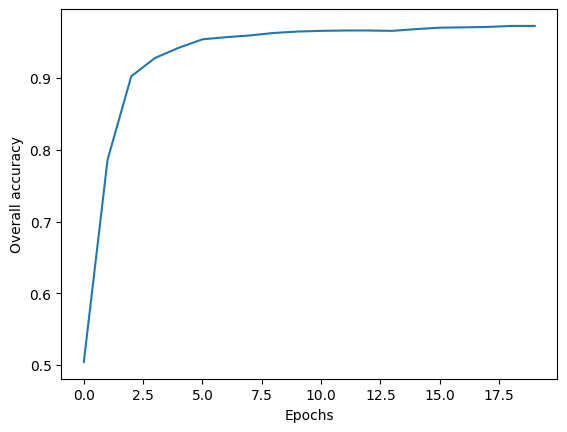

In [81]:
vals = learner.recorder.values
acc = [v[2] for v in vals]
plt.plot(acc)
plt.xlabel('Epochs')
plt.ylabel("Overall accuracy")
plt.show()

# Multi-class MNIST classification

The MNIST dataset contains all 10 digits from 0 to 9. To train a classifier that can recognize multiple digits, a few modifications to the model described above are necessary. First, the output layer of the neural network should have 10 output neurons, meaning it will predict 10 values instead of just one. Each output will represent the log-odds for a specific digit. Second, I will use the loss function `nn.CrossEntropyLoss()`, which expects raw log-odds as input and integer class labels as targets. This loss function is commonly used for multi-class classification. Internally, it applies `log(softmax(output))`, selects the value corresponding to the correct class, and computes the negative log-likelihood. The softmax function, used in both machine learning and statistics, converts raw log-odds into probabilities such that all values sum to 1.

Let's download the data and check out its structure.

In [82]:
path = untar_data(URLs.MNIST)
path

Path('/root/.fastai/data/mnist_png')

In [86]:
paths = (path/'training').ls() + (path/'testing').ls()
short_paths = [Path(*path.parts[-2:]) for path in paths]
n_images = [len(path.ls()) for path in paths]
list(zip(short_paths, n_images))

[(Path('training/1'), 6742),
 (Path('training/3'), 6131),
 (Path('training/7'), 6265),
 (Path('training/6'), 5918),
 (Path('training/5'), 5421),
 (Path('training/0'), 5923),
 (Path('training/9'), 5949),
 (Path('training/2'), 5958),
 (Path('training/4'), 5842),
 (Path('training/8'), 5851),
 (Path('testing/1'), 1135),
 (Path('testing/3'), 1010),
 (Path('testing/7'), 1028),
 (Path('testing/6'), 958),
 (Path('testing/5'), 892),
 (Path('testing/0'), 980),
 (Path('testing/9'), 1009),
 (Path('testing/2'), 1032),
 (Path('testing/4'), 982),
 (Path('testing/8'), 974)]

Check out one of the images. It looks like it's in the same format as the sample dataset.

(28, 28)


<Axes: >

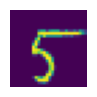

In [87]:
img_path = (path/'training'/'5').ls()[1000]
img = Image.open(img_path)
print(img.shape)
show_image(img)

## ImageDataLoaders: easy loading of data

The dataset contains training and testing, but no folder reserved for validation. Technically, testing data is intended to be the never-before-seen dataset that the model should be evaluated on. For the sake of simplicity, I'm just going to treat the testing data as validation like I did in the previous example.

Instead of creating a `DataLoaders` object from scratch, I'm using the `ImageDataLoaders` class, which simplifies much of the setup. I use the `from_folder()` method to load images from a directory, specify which folders correspond to training and validation data, and define the batch size. Since the images are organized in folders named after their labels, the method automatically assigns the target values (`y`).

By default, `ImageDataLoaders` loads images as RGB, but the MNIST data is grayscale. To reflect that, I specify `PILImageBW`, which also ensures the pixel values are normalized between 0 and 1.

There's one caveat: I couldn't directly flatten the image data (`x`) within the data loading process without also affecting the target labels (`y`). This isn't typically an issue, as you usually want to preserve the 2D structure of images for convolutional neural networks. However, for a basic neural network like the one I'm building, the input needs to be flattened. Additionally, while the previous binary classification required target labels as a matrix, `nn.CrossEntropyLoss()` for multi-class classification expects `y` to be a vector. Since I couldn't figure out how to apply separate transformations for `x` and `y` during data loading, my solution was to include `nn.Flatten()` at the start of my neural network model.

In [89]:

dls_multi = ImageDataLoaders.from_folder(path, # parent path to images
                                   train = 'training', # folder name for training
                                   valid = 'testing', # folder name for validation
                                   bs=256, # batch size
                                   img_cls=PILImageBW # load images as grayscale rather than default RGB
                                   )

xb, yb = dls_multi.one_batch()
# x is not flat--its a stack of images with a greyscale band. Will flatten in the NN model.
xb.shape, yb.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

## Custom NN Model

Like I already stated, I'll need to create a NN model that flattens the image. That's what `nn.Flatten()` does. The rest of the model is very similar to the one I wrote in the binary classification. Differences are...

1. There are 10 output nodes in the output layer because we are predicting the log-odds of each of the 10 digit classes.
2. I do not transform the output layer with a sigmoid function. This is because the loss function expects raw log-odds rather than probabilities.  

In [90]:

def nn_1hidden_multi(nodes, coefs = 784, outputs = 10):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(coefs, nodes),
        nn.ReLU(),
        nn.Linear(nodes, outputs)
    )



## Train model and evaluate

I specify the same parameters in the Learner class as before. One thing that I have not addressed yet is the metrics function `accuracy`. This is a built in function that is set up to automatically interpret the model's output.

Running this takes a lot more compute power, so I ran this on Google Colab with GPU resources. 

In [91]:
learner_multi2 = Learner(
    dls = dls_multi,
    model= nn_1hidden_multi(nodes=30),
    loss_func= nn.CrossEntropyLoss(),
    opt_func=SGD,
    metrics=accuracy
)

lr = .5
learner_multi2.fit(5, lr)

epoch,train_loss,valid_loss,accuracy,time
0,0.302452,0.246996,0.928200,00:52
1,0.203011,0.188507,0.943600,00:54
2,0.170280,0.160384,0.951500,00:54
3,0.151577,0.141061,0.957200,00:50
4,0.132551,0.123016,0.962800,00:47


Lastly, let's check out a confusion matrix. There are plenty more ways to evaluate how well the model performed, but this is a fast, easy way to see how well the model classified the 10 different digits.

In [92]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Get predictions and true labels from the validation set
preds, targets = learner_multi2.get_preds()

# Get the predicted class for each sample by choosing the one w/ highest log-odds
predicted_classes = torch.argmax(preds, dim=1)

# Compute the confusion matrix
cm = confusion_matrix(targets, predicted_classes)

# Display the confusion matrix using pandas DataFrame for better readability
display(pd.DataFrame(cm))

,0,1,2,3,4,5,6,7,8,9
0,967,0,1,1,1,1,4,2,2,1
1,0,1117,4,4,1,1,2,1,5,0
2,5,2,993,6,7,0,7,8,4,0
3,0,0,7,977,0,10,0,7,6,3
4,1,0,5,1,945,1,4,4,2,19
5,6,1,1,8,1,853,8,1,7,6
6,8,3,3,0,4,7,931,0,2,0
7,1,6,14,8,3,0,1,979,2,14
8,5,3,9,10,5,8,7,7,919,1
9,5,7,1,11,16,7,1,9,5,947
